# Training behaviour and selected checkpoints

This notebook reproduces the validation-loss figure used in the Results
chapter. Stars mark the checkpoints used for final evaluation. Checkpoint
selection is based on validation data only; the U-Net ensemble full run uses epoch 0 in the final evaluation because this
checkpoint has the lowest recorded validation CRPS within that run.

## Paths and selected epochs

In [1]:

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

%matplotlib inline

MLCAST_ROOT = Path("/data/brussel/114/vsc11442/code/mlcast-ldcast")
CONVGRU_ROOT = Path("/data/brussel/114/vsc11442/code/convgru-ensemble")
UNET_ROOT = Path("/data/brussel/114/vsc11442/code/mlcast-unet")
SCRATCH_ROOT = Path(os.environ.get("VSC_SCRATCH", "/scratch/brussel/114/vsc11442"))

FIG_DIR = (
    MLCAST_ROOT
    / "results"
    / "evaluation"
    / "test_2021_6hourly"
    / "figures_results"
)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Final run locations used in the thesis.
CONVGRU_DET_RUNS = {
    "10%": MLCAST_ROOT / "results/convgru/convgru_10pct_b32_crop256/lightning_logs",
    "full": MLCAST_ROOT / "results/convgru/convgru_full_b32_crop256/lightning_logs",
}

ENS_LOG_ROOT = CONVGRU_ROOT / "logs/CRPS_4past-20fut_noise"
CONVGRU_ENS_RUNS = {
    "10%": [
        ENS_LOG_ROOT / "job12369419_4past-20fut_noise_bs32_lr1e-05",
        ENS_LOG_ROOT / "job12854430_4past-20fut_noise_bs32_lr1e-05_resume_to30_from_job12369419",
    ],
    "full": [
        ENS_LOG_ROOT / "job12369418_4past-20fut_noise_bs32_lr1e-05",
        ENS_LOG_ROOT / "job12854429_4past-20fut_noise_bs32_lr1e-05_resume_to3_from_job12369418",
    ],
}

UNET_RUNS = {
    "U-Net 10%": UNET_ROOT / "logs/unet_10pct_crop256_b32",
    "U-Net full": UNET_ROOT / "logs/unet_full_crop256_b32",
    "U-Net ensemble 10%": UNET_ROOT / "logs/stoch_unet_10pct_crop128_b32",
    "U-Net ensemble full": UNET_ROOT / "logs/stoch_unet_full_crop128_b32",
}

LDCAST_ARCHIVE = SCRATCH_ROOT / "mlcast_runs_archive/ldcast"
LDCAST_RUNS = {
    "10%": LDCAST_ARCHIVE / "genforecast_10pct_crop128_ae256_b32",
    "full": MLCAST_ROOT / "results/ldcast/genforecast_full_crop128_ae256_b32",
}

SELECTED_EPOCHS = {
    "ConvGRU 10%": 17,
    "ConvGRU full": 1,
    "ConvGRU ensemble 10%": 29,
    "ConvGRU ensemble full": 2,
    "U-Net 10%": 43,
    "U-Net full": 4,
    "U-Net ensemble 10%": 47,
    "U-Net ensemble full": 0,
    "LDCast 10%": 29,
    "LDCast full": 2,
}

## Log-reading helpers

In [2]:
import re

def _tb_scalar_table(event_file, tag):
    """Read one TensorBoard scalar and attach the logged Lightning epoch."""
    ea = EventAccumulator(
        str(event_file),
        size_guidance={"scalars": 0},
    )
    ea.Reload()

    tags = set(ea.Tags().get("scalars", []))
    if tag not in tags:
        return pd.DataFrame(columns=["epoch", "step", "wall_time", "value"])

    metric_events = ea.Scalars(tag)
    metric = pd.DataFrame(
        {
            "step": [e.step for e in metric_events],
            "wall_time": [e.wall_time for e in metric_events],
            "value": [e.value for e in metric_events],
        }
    ).sort_values(["step", "wall_time"])

    if "epoch" in tags:
        epoch_events = ea.Scalars("epoch")
        epoch = pd.DataFrame(
            {
                "step": [e.step for e in epoch_events],
                "epoch": [e.value for e in epoch_events],
                "epoch_wall_time": [e.wall_time for e in epoch_events],
            }
        )
        epoch = (
            epoch.sort_values(["step", "epoch_wall_time"])
            .drop_duplicates("step", keep="last")
        )
        metric = pd.merge_asof(
            metric.sort_values("step"),
            epoch[["step", "epoch"]].sort_values("step"),
            on="step",
            direction="backward",
        )
    else:
        metric["epoch"] = np.nan

    return metric


def read_tb_tag(run_dir, tag):
    """Read one scalar tag from every TensorBoard event file below a run."""
    run_dir = Path(run_dir)
    tables = []

    for event_file in sorted(run_dir.rglob("events.out.tfevents*")):
        table = _tb_scalar_table(event_file, tag)
        if not table.empty:
            table["event_file"] = str(event_file)
            tables.append(table)

    if not tables:
        return pd.DataFrame(columns=["epoch", "step", "wall_time", "value"])

    return pd.concat(tables, ignore_index=True)


def clean_epoch_series(df, max_epoch=None):
    """Keep the latest logged value for each actual Lightning epoch."""
    if df.empty:
        return pd.DataFrame(columns=["epoch", "value"])

    out = df.dropna(subset=["epoch", "value"]).copy()
    out["epoch"] = out["epoch"].round().astype(int)

    if max_epoch is not None:
        out = out[out["epoch"] <= int(max_epoch)]

    return (
        out.sort_values(["epoch", "wall_time", "step"])
        .drop_duplicates("epoch", keep="last")
        [["epoch", "value"]]
        .reset_index(drop=True)
    )


def combine_tb_runs(run_dirs, tag, max_epoch=None):
    """Combine initial and resumed runs, keeping the latest record per epoch."""
    tables = []
    for run_order, run_dir in enumerate(run_dirs):
        table = read_tb_tag(run_dir, tag)
        if table.empty:
            continue
        table["run_order"] = run_order
        tables.append(table)

    if not tables:
        return pd.DataFrame(columns=["epoch", "value"])

    combined = pd.concat(tables, ignore_index=True)
    combined = combined.sort_values(["wall_time", "run_order", "step"])
    return clean_epoch_series(combined, max_epoch=max_epoch)


def version_number(path):
    match = re.search(r"version_(\d+)", str(path))
    return int(match.group(1)) if match else -1


def load_lightning_csv_run(run_dir):
    """Combine Lightning CSVLogger files across resumed versions."""
    run_dir = Path(run_dir)
    files = sorted(
        run_dir.glob("lightning_logs/version_*/metrics.csv"),
        key=version_number,
    )
    if not files:
        files = sorted(run_dir.rglob("metrics.csv"))
    if not files:
        raise FileNotFoundError(f"No metrics.csv found below {run_dir}")

    frames = []
    for path in files:
        frame = pd.read_csv(path)
        frame["_version"] = version_number(path)
        frame["_row"] = np.arange(len(frame))
        frames.append(frame)

    return pd.concat(frames, ignore_index=True, sort=False)


def ldcast_val_series(run_dir, max_epoch):
    metrics = load_lightning_csv_run(run_dir)
    if "epoch" not in metrics or "val/loss_epoch" not in metrics:
        raise KeyError(f"Missing LDCast validation columns under {run_dir}")

    out = metrics[["epoch", "step", "val/loss_epoch", "_version", "_row"]].dropna()
    out["epoch"] = out["epoch"].round().astype(int)
    out = out[out["epoch"] <= int(max_epoch)]
    out = (
        out.sort_values(["epoch", "step", "_version", "_row"])
        .drop_duplicates("epoch", keep="last")
        .rename(columns={"val/loss_epoch": "value"})
    )
    return out[["epoch", "value"]].reset_index(drop=True)

## Load validation-loss series

In [3]:

# Deterministic ConvGRU (Lightning CSV logs).
def load_convgru_det_series(log_dir, max_epoch):
    files = sorted(Path(log_dir).glob("version_*/metrics.csv"))
    if not files:
        raise FileNotFoundError(f"No metrics.csv found below {log_dir}")

    frames = [pd.read_csv(path) for path in files]
    df = pd.concat(frames, ignore_index=True, sort=False)

    out = df[["epoch", "step", "val/loss_epoch"]].dropna()
    out["epoch"] = out["epoch"].round().astype(int)
    out = out[out["epoch"] <= int(max_epoch)]
    out = (
        out.sort_values(["epoch", "step"])
        .drop_duplicates("epoch", keep="last")
        .rename(columns={"val/loss_epoch": "value"})
    )
    return out[["epoch", "value"]].reset_index(drop=True)


series = {
    "ConvGRU 10%": load_convgru_det_series(CONVGRU_DET_RUNS["10%"], 29),
    "ConvGRU full": load_convgru_det_series(CONVGRU_DET_RUNS["full"], 2),
    "ConvGRU ensemble 10%": combine_tb_runs(
        CONVGRU_ENS_RUNS["10%"], "val_loss", max_epoch=29
    ),
    "ConvGRU ensemble full": combine_tb_runs(
        CONVGRU_ENS_RUNS["full"], "val_loss", max_epoch=2
    ),
}

for model_name, run_dir in UNET_RUNS.items():
    max_epoch = 49 if "10%" in model_name else 4
    series[model_name] = clean_epoch_series(
        read_tb_tag(run_dir, "val_loss"),
        max_epoch=max_epoch,
    )

series["LDCast 10%"] = ldcast_val_series(LDCAST_RUNS["10%"], 29)
series["LDCast full"] = ldcast_val_series(LDCAST_RUNS["full"], 2)

for name, values in series.items():
    print(f"{name:24s} -> {len(values):2d} validation epochs")

ConvGRU 10%              -> 30 validation epochs
ConvGRU full             ->  3 validation epochs
ConvGRU ensemble 10%     -> 30 validation epochs
ConvGRU ensemble full    ->  3 validation epochs
U-Net 10%                -> 50 validation epochs
U-Net full               ->  5 validation epochs
U-Net ensemble 10%       -> 50 validation epochs
U-Net ensemble full      ->  5 validation epochs
LDCast 10%               -> 30 validation epochs
LDCast full              ->  3 validation epochs


## Plot the final training-loss figure

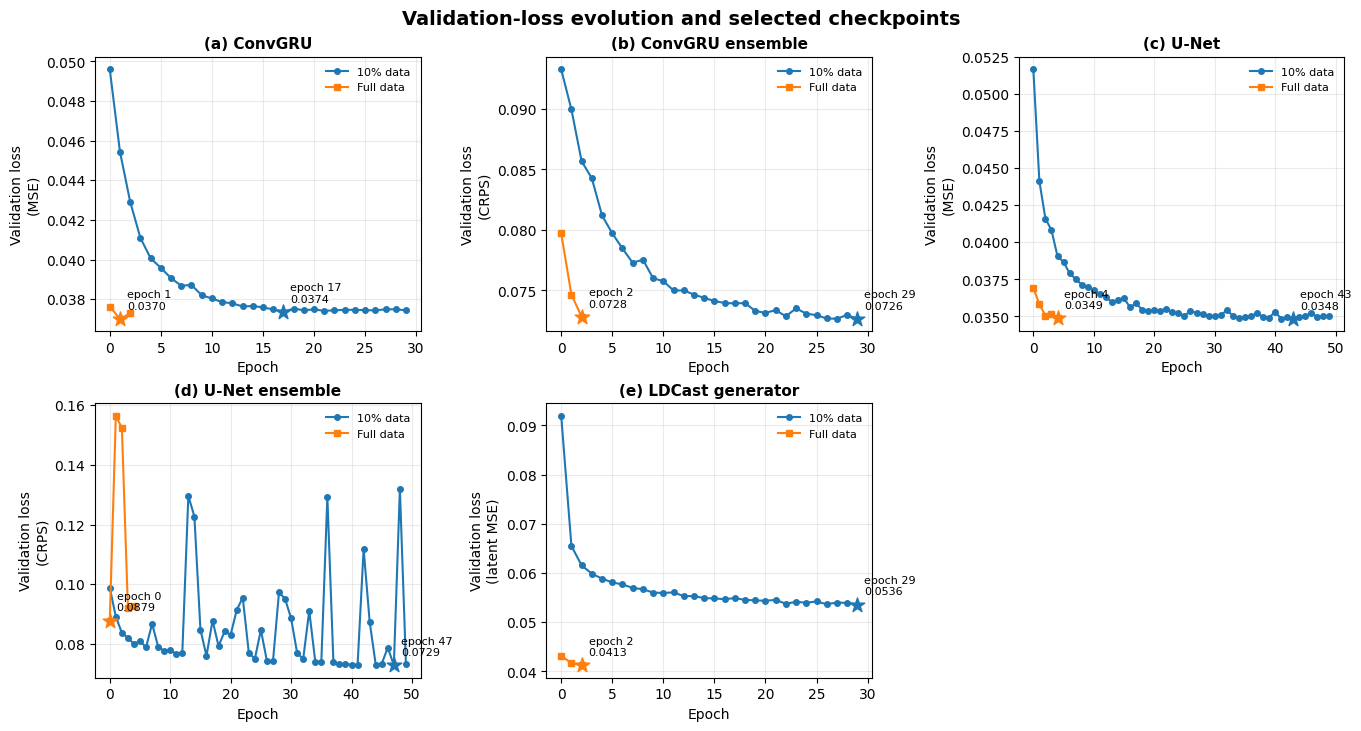

Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/results_training_losses.png

Selected checkpoints shown in the figure:
ConvGRU 10%               epoch=17 val=0.037366
ConvGRU full              epoch= 1 val=0.037004
ConvGRU ensemble 10%      epoch=29 val=0.072648
ConvGRU ensemble full     epoch= 2 val=0.072840
U-Net 10%                 epoch=43 val=0.034830
U-Net full                epoch= 4 val=0.034879
U-Net ensemble 10%        epoch=47 val=0.072935
U-Net ensemble full       epoch= 0 val=0.087898
LDCast 10%                epoch=29 val=0.053604
LDCast full               epoch= 2 val=0.041267


In [4]:

def plot_family(ax, name_10, name_full, title, objective):
    for name, marker, split_label in [
        (name_10, "o", "10% data"),
        (name_full, "s", "Full data"),
    ]:
        values = series[name]
        if values.empty:
            continue

        ax.plot(
            values["epoch"],
            values["value"],
            marker=marker,
            markersize=4,
            linewidth=1.5,
            label=split_label,
        )

        selected_epoch = SELECTED_EPOCHS[name]
        selected = values[values["epoch"] == selected_epoch]
        if selected.empty:
            raise ValueError(
                f"Selected epoch {selected_epoch} is missing for {name}"
            )

        selected_value = float(selected.iloc[-1]["value"])
        ax.scatter(
            selected_epoch,
            selected_value,
            marker="*",
            s=120,
            zorder=6,
        )
        ax.annotate(
            f"epoch {selected_epoch}\n{selected_value:.4f}",
            xy=(selected_epoch, selected_value),
            xytext=(5, 7),
            textcoords="offset points",
            fontsize=8,
        )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(f"Validation loss\n({objective})")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, frameon=False)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(13.5, 7.2),
    constrained_layout=True,
)
axes = axes.ravel()

plot_family(
    axes[0],
    "ConvGRU 10%",
    "ConvGRU full",
    "(a) ConvGRU",
    "MSE",
)
plot_family(
    axes[1],
    "ConvGRU ensemble 10%",
    "ConvGRU ensemble full",
    "(b) ConvGRU ensemble",
    "CRPS",
)
plot_family(
    axes[2],
    "U-Net 10%",
    "U-Net full",
    "(c) U-Net",
    "MSE",
)
plot_family(
    axes[3],
    "U-Net ensemble 10%",
    "U-Net ensemble full",
    "(d) U-Net ensemble",
    "CRPS",
)
plot_family(
    axes[4],
    "LDCast 10%",
    "LDCast full",
    "(e) LDCast generator",
    "latent MSE",
)
axes[5].axis("off")

fig.suptitle(
    "Validation-loss evolution and selected checkpoints",
    fontsize=14,
    fontweight="bold",
)

output_path = FIG_DIR / "results_training_losses.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

print("\nSelected checkpoints shown in the figure:")
for name, selected_epoch in SELECTED_EPOCHS.items():
    values = series[name]
    selected = values[values["epoch"] == selected_epoch]
    selected_value = float(selected.iloc[-1]["value"])
    print(f"{name:25s} epoch={selected_epoch:2d} val={selected_value:.6f}")